In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('plot_style')
from PCX_sim.core.pcx_functions import *
from matplotlib.lines import Line2D

In [4]:
He_e_ion = CrossSection('electron', 'He', 'He+', '../cross_sections/He_e_He+.txt')
He_H_ion = CrossSection('H', 'He', 'He+', '../cross_sections/He_H_He+.txt')
He_p_ion = CrossSection('H+', 'He', 'ionHe+', '../cross_sections/He_H+_He+_H+.txt')
He_p_cx = CrossSection('H+', 'He', 'cxHe+', '../cross_sections/He_H+_He+_H.txt')

He1_e_ion = CrossSection('electron', 'He+', 'He2+', '../cross_sections/He+_e_He2+.txt')
He1_H_ion = CrossSection('H', 'He+', 'He2+', '../cross_sections/He+_H_He2+.txt')
He1_H_cx = CrossSection('H', 'He+', 'He', '../cross_sections/He+_H_He.txt')
He1_p_ion = CrossSection('H+', 'He+', 'ionHe2+', '../cross_sections/He+_H+_He2+_H+.txt')
He1_p_cx = CrossSection('H+', 'He+', 'cxHe2+', '../cross_sections/He+_H+_He2+_H.txt')

He2_H_cx = CrossSection('H', 'He2+', 'He+', '../cross_sections/He2+_H_He+_H+.txt')

cross_sections = CrossSectionCollection([He2_H_cx, He1_H_cx, He1_e_ion, He1_H_ion, He1_p_ion, He1_p_cx,
                                         He_e_ion, He_H_ion, He_p_ion, He_p_cx])

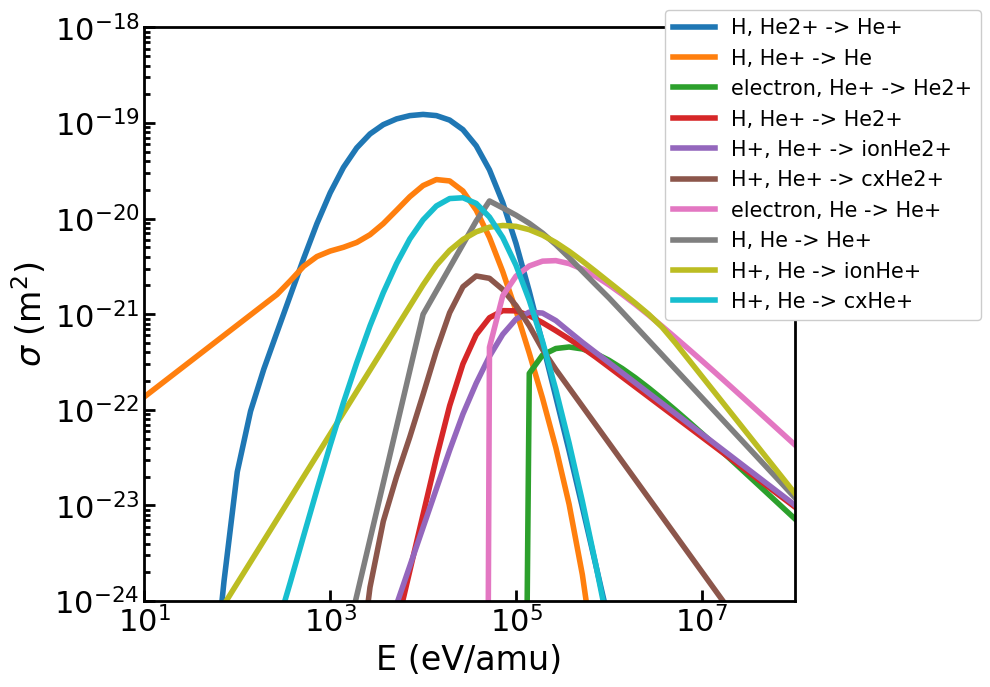

In [ ]:
test_E = 10**np.linspace(1, 8, 50)
plt.gcf().set_size_inches(10,7)
for cross in cross_sections.cross_sections:
    plt.plot(test_E, cross.cross_section(test_E))
plt.xlim(min(test_E),max(test_E))
plt.yscale('log')
plt.xscale('log')
plt.ylim(bottom = 1e-24, top=1e-18)
plt.xlabel('E (eV/amu)')
plt.ylabel(r'$\sigma$ (m$^2$)')
plt.legend(cross_sections.cross_sections, fontsize = 15, loc=(0.8,0.49), framealpha=1)
#plt.savefig(f'plots/cross_sections.png', bbox_inches='tight')
plt.show()

In [6]:
n_plasma = 1e20
T_plasma = 10e3
n_H = 1e24
T_H = 1e-2
E_He = 1e6
dt = 1e-12
N = 6000
n_He0 = 1e17


comp = PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N)

In [7]:
comp.n_He1

array([0.00000000e+00, 1.24471140e+14, 2.48136575e+14, ...,
       2.03331900e+16, 2.03331900e+16, 2.03331900e+16])

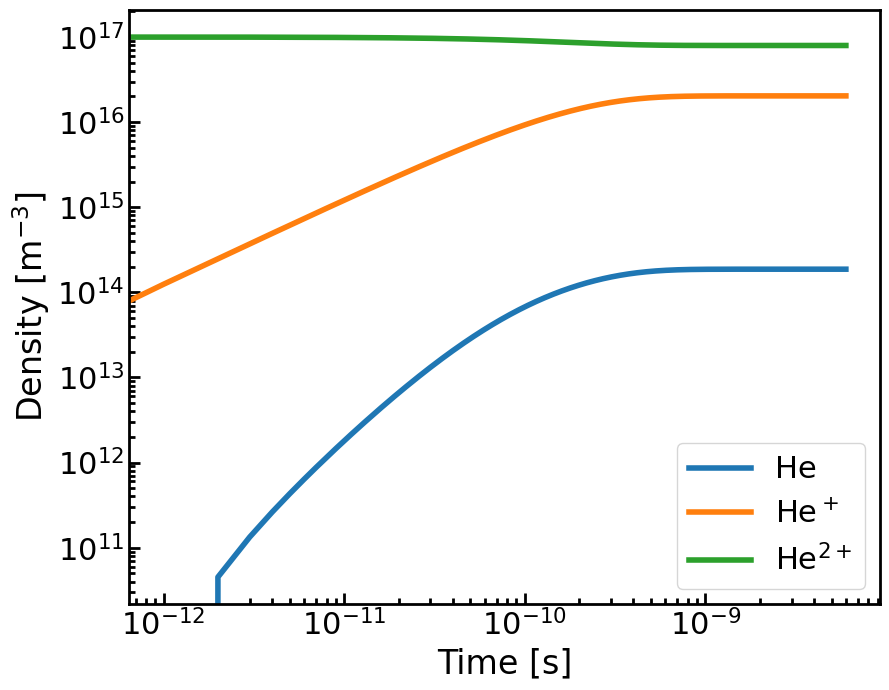

In [8]:

plt.plot(comp.time, comp.n_He)
plt.plot(comp.time, comp.n_He1)
plt.plot(comp.time, comp.n_He2)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'Density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.title('')
plt.legend(['He', r'He$^+$', r'He$^{2+}$'])
#plt.savefig(f'plots/example.png', bbox_inches='tight')
plt.show()

# Pellet density

In [85]:
n_plasma = 1e19
T_plasma = 10e3
n_H_list = 10**np.array([18, 19, 20, 22, 25, 28], dtype=float)
T_H = 1e-2
E_He = 1e6
dt_list = [1e-6, 1e-7, 1e-8, 1e-10, 1e-13, 1e-16]
N = 10000
n_He0 = 1e16
n_H_scan = []

for i,n_H in enumerate(n_H_list):
    n_H_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt_list[i], N))

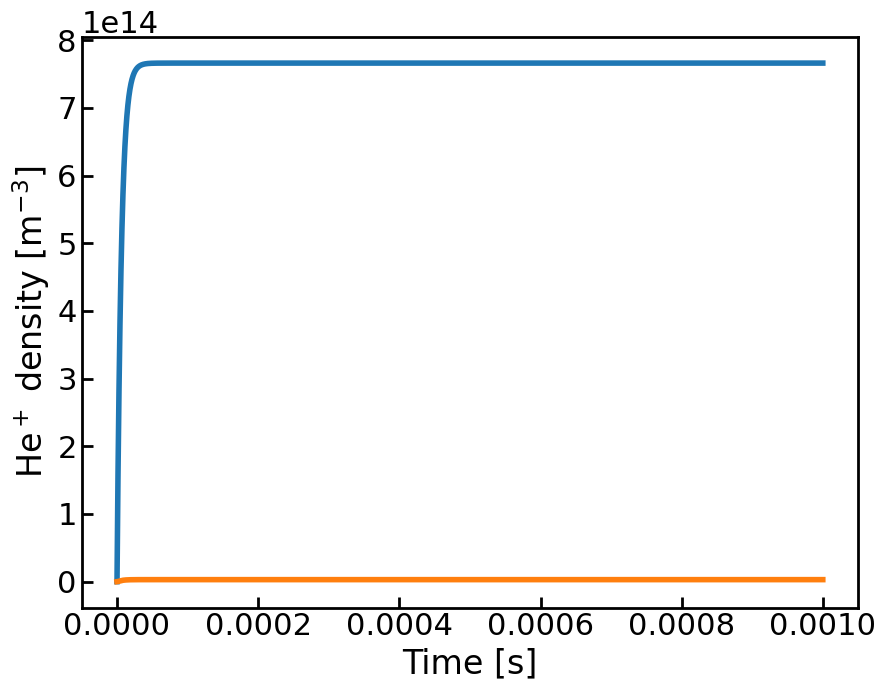

In [86]:
ind = 1
plt.plot(n_H_scan[ind].time, n_H_scan[ind].n_He1)
plt.plot(n_H_scan[ind].time, n_H_scan[ind].n_He)
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
#plt.xlim(left=0, right=0.3e-5)
#plt.yscale('log')
#plt.title('Cloud density scan')
#plt.savefig(f'plots/equilibrium_example.png', bbox_inches='tight')
plt.show()

In [87]:
for run in n_H_scan:
    run.time[0] = run.time[1]/10

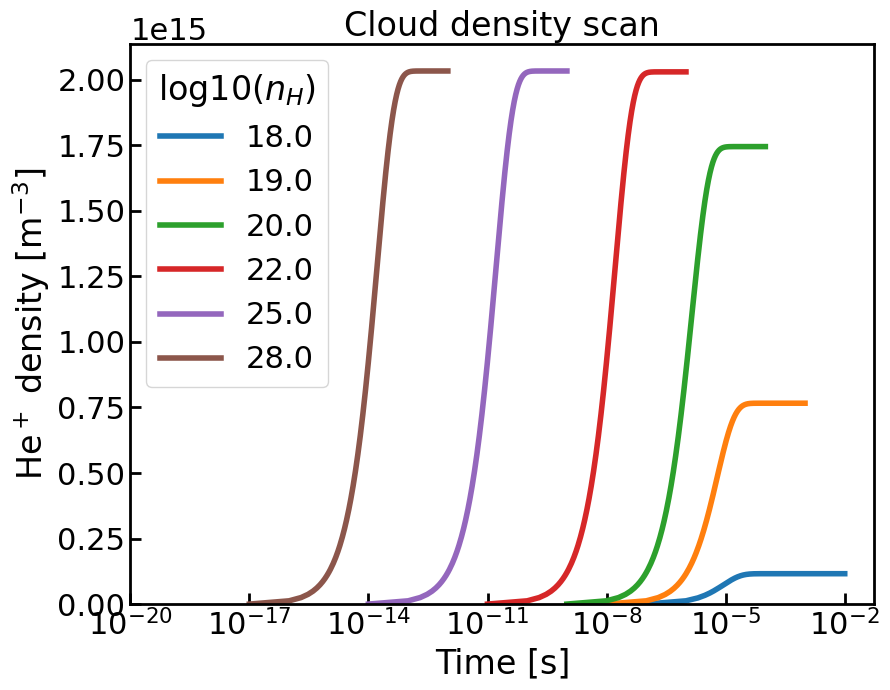

In [ ]:
for run in n_H_scan:
    plt.plot(run.time, run.n_He1)
#plt.yscale('log')
plt.xscale('log')
plt.ylim(bottom=0)
plt.xlim(left=1e-20)
plt.legend(np.log10(n_H_list), title=r'log10($n_H$)')
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.title('Cloud density scan')
#plt.savefig(f'plots/cloud_density.png', bbox_inches='tight')
plt.show()

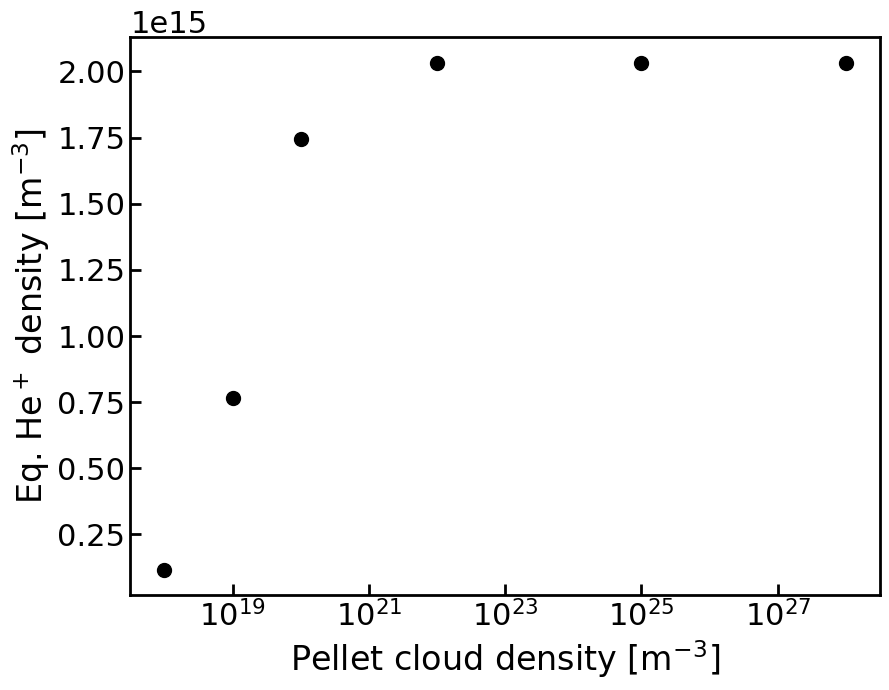

In [ ]:
for i,run in enumerate(n_H_scan):
    plt.scatter(n_H_list[i], run.n_He1[-1], c='k')
#plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'Pellet cloud density [m$^{-3}$]')
plt.ylabel(r'Eq. He$^+$ density [m$^{-3}$]')
#plt.savefig(f'plots/eq_cloud_density.png', bbox_inches='tight')
plt.show()

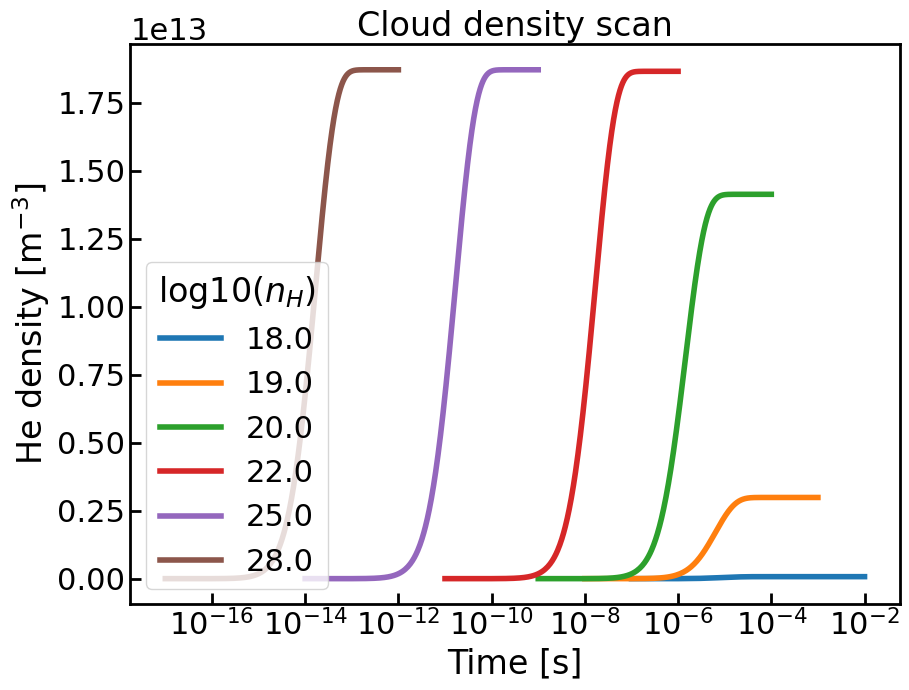

In [91]:
for run in n_H_scan:
    plt.plot(run.time, run.n_He)
#plt.yscale('log')
plt.xscale('log')
plt.legend(np.log10(n_H_list), title=r'log10($n_H$)')
plt.ylabel(r'He density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.title('Cloud density scan')
#plt.savefig(f'plots/cloud_density.png', bbox_inches='tight')
plt.show()

# Plasma density

In [97]:
n_plasma_list = 10**np.array([19, 20, 22, 24, 26], dtype=float)
T_plasma = 10e3
n_H = 1e24
T_H = 1e-2
E_He = 1e6
dt = 1e-13
N = 10000
n_He0 = 1e16
n_plasma_scan = []

for n_plasma in n_plasma_list:
    n_plasma_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N))

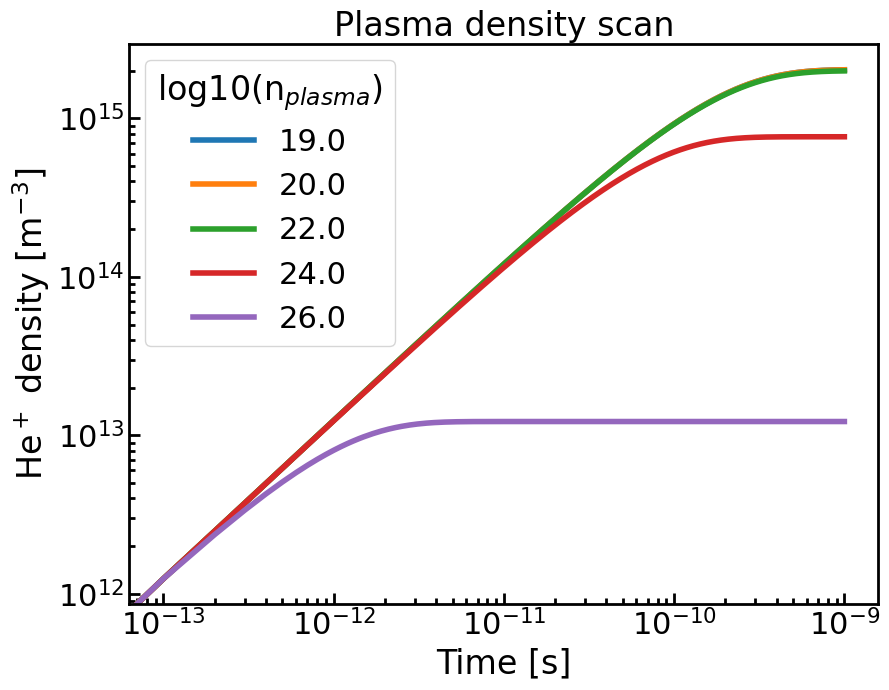

In [ ]:
for run in n_plasma_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.legend(np.log10(n_plasma_list), title=r'log10(n$_{plasma}$)')
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.title('Plasma density scan')
#plt.savefig(f'plots/plasma_density.png', bbox_inches='tight')
plt.show()

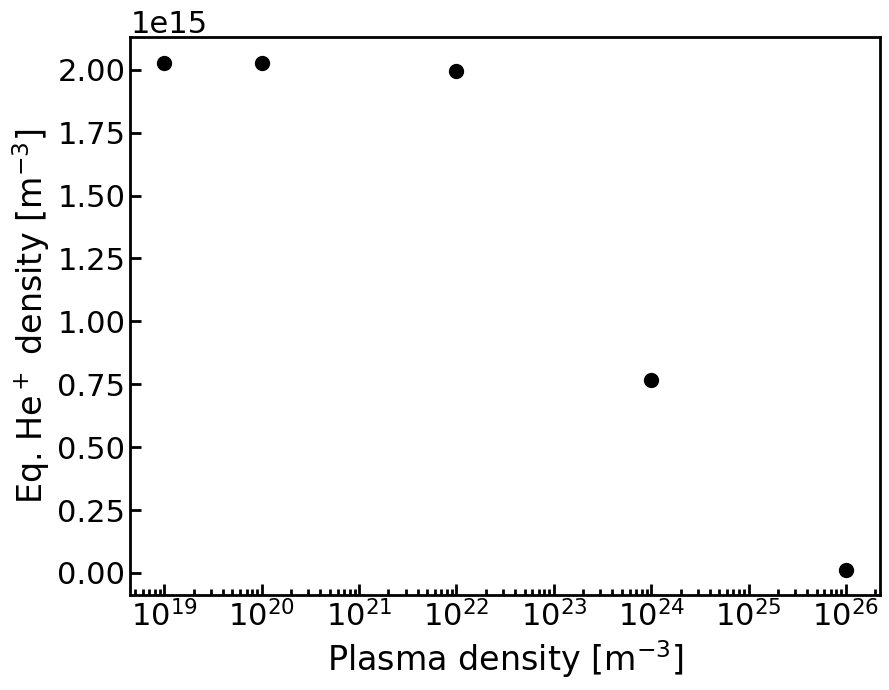

In [ ]:
for i,run in enumerate(n_plasma_scan):
    plt.scatter(n_plasma_list[i], run.n_He1[-1], c='k')
#plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'Plasma density [m$^{-3}$]')
plt.ylabel(r'Eq. He$^+$ density [m$^{-3}$]')
#plt.savefig(f'plots/eq_plasma_density.png', bbox_inches='tight')
plt.show()

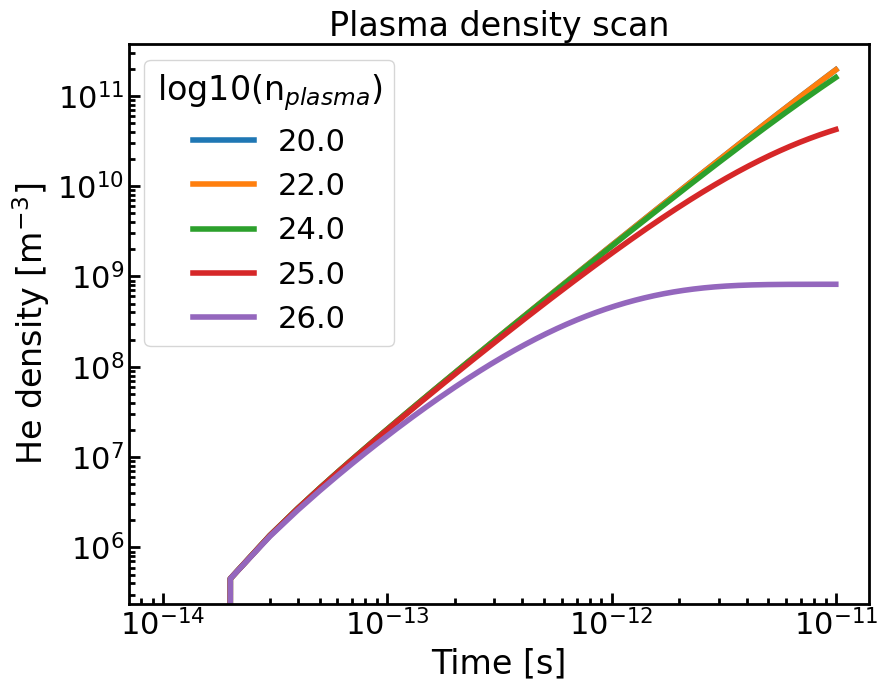

In [16]:
for run in n_plasma_scan:
    plt.plot(run.time, run.n_He)
plt.yscale('log')
plt.xscale('log')
plt.legend(np.log10(n_plasma_list), title=r'log10(n$_{plasma}$)')
plt.ylabel(r'He density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.title('Plasma density scan')
#plt.savefig(f'plots/plasma_density.png', bbox_inches='tight')
plt.show()

# Plasma temperature

In [103]:
n_plasma = 1e20
T_plasma_list = np.linspace(1e3, 30e3, 7)
n_H = 1e22
T_H = 1e-2
E_He = 1e6
dt = 1e-11
N = 50000
n_He0 = 1e16
T_plasma_scan = []

for T_plasma in T_plasma_list:
    T_plasma_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N))

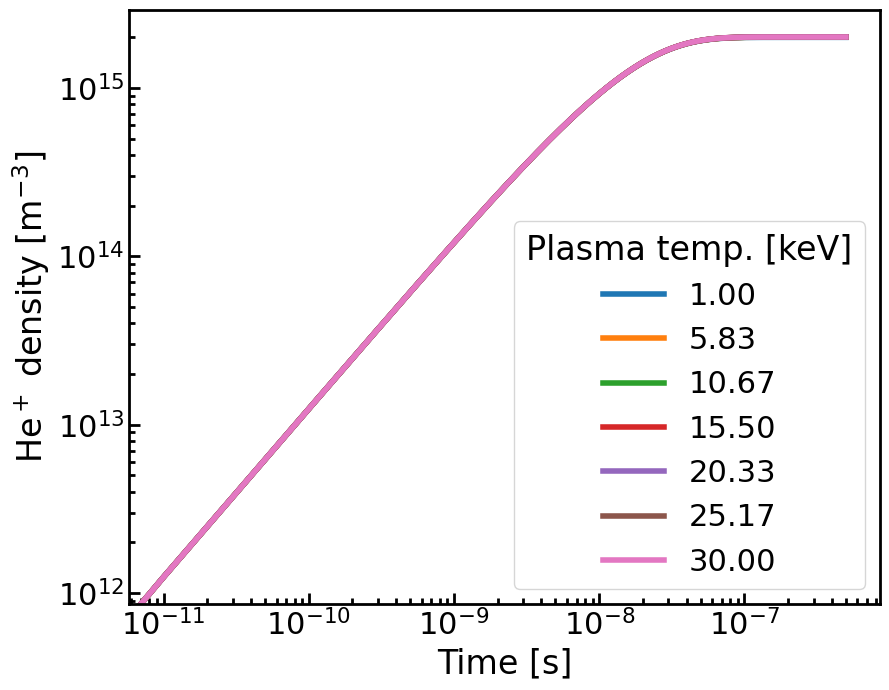

In [ ]:
for run in T_plasma_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.legend([f'{t/1e3:.2f}' for t in T_plasma_list], title='Plasma temp. [keV]')
#plt.savefig(f'plots/plasma_temp.png', bbox_inches='tight')
plt.show()

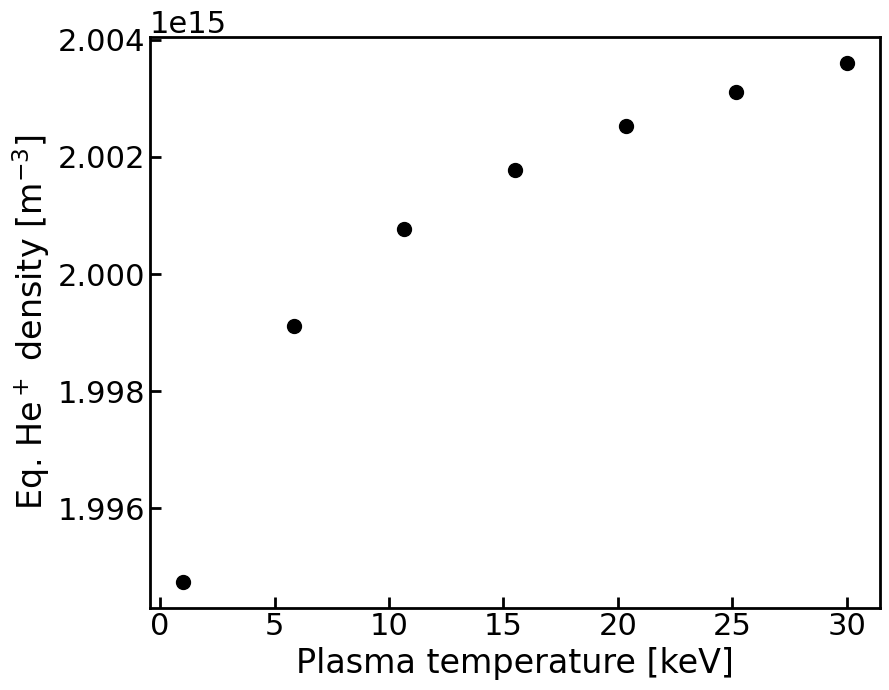

In [ ]:
for i,run in enumerate(T_plasma_scan):
    plt.scatter(T_plasma_list[i]/1000, run.n_He1[-1], c='k')
plt.xlabel(r'Plasma temperature [keV]')
plt.ylabel(r'Eq. He$^+$ density [m$^{-3}$]')
#plt.savefig(f'plots/eq_plasma_temp.png', bbox_inches='tight')
plt.show()

# Pellet temperature

In [108]:
n_plasma = 1e22
T_plasma = 10e3
n_H = 1e22
T_H_list = np.linspace(1e-3, 2e-2, 7)
E_He = 1e6
dt = 1e-11
N = 50000
n_He0 = 1e16
T_H_scan = []

for T_H in T_H_list:
    T_H_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N))

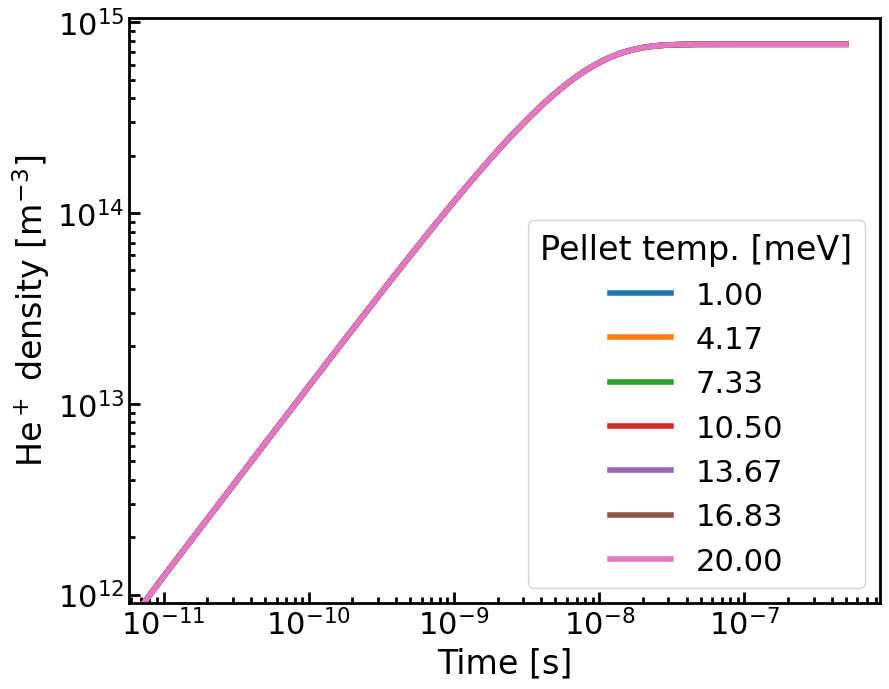

In [ ]:
for run in T_H_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.legend([f'{t/1e-3:.2f}' for t in T_H_list], title='Pellet temp. [meV]')
#plt.savefig(f'plots/pellet_temp.png', bbox_inches='tight')
plt.show()

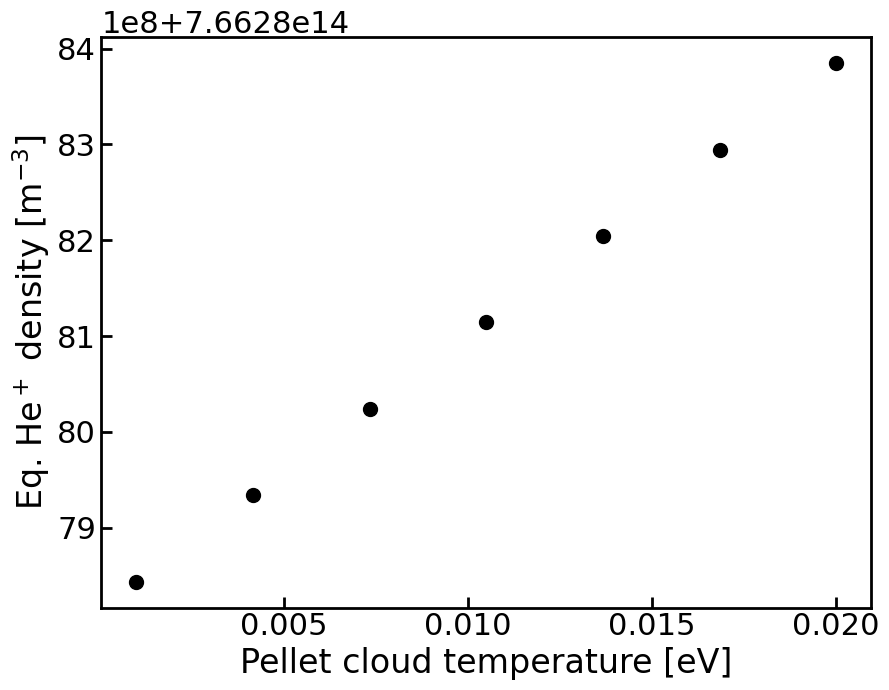

In [ ]:
for i,run in enumerate(T_H_scan):
    plt.scatter(T_H_list[i], run.n_He1[-1], c='k')
plt.xlabel(r'Pellet cloud temperature [eV]')
plt.ylabel(r'Eq. He$^+$ density [m$^{-3}$]')
#plt.savefig(f'plots/pellet_temp.png', bbox_inches='tight')
plt.show()

# He energy

In [115]:
n_plasma = 1e20
T_plasma = 10e3
n_H = 1e24
T_H = 1e-2
E_He_list = np.arange(1e6, 5.3e6, 5e5)
dt = 1e-12
N = 10000
n_He0 = 1e16
E_He_scan = []

for E_He in E_He_list:
    E_He_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N))

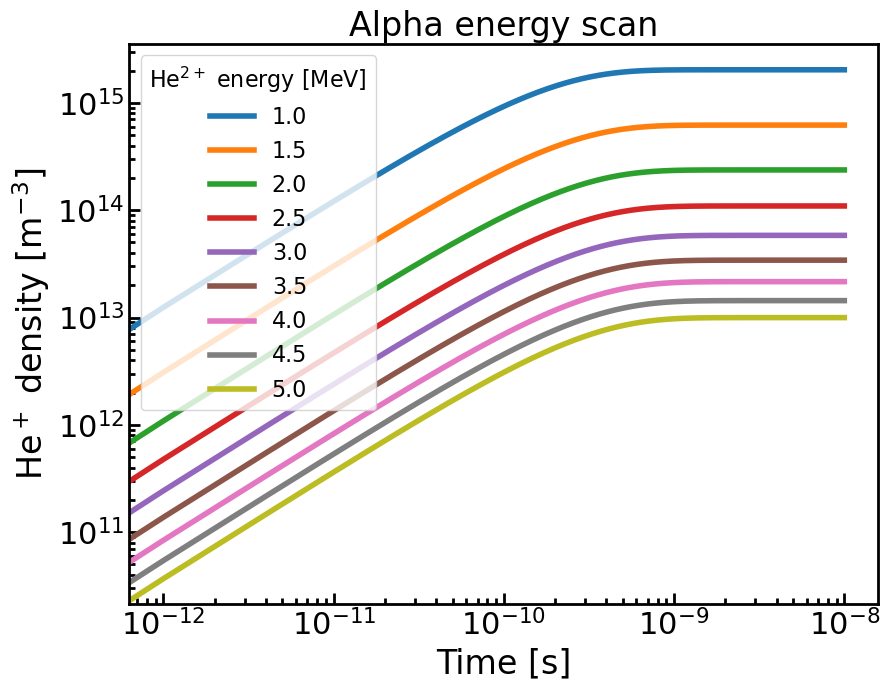

In [ ]:
for run in E_He_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.legend(E_He_list/1e6, title=r'He$^{2+}$ energy [MeV]', fontsize=16, title_fontsize=16)
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
plt.title('Alpha energy scan')
#plt.savefig(f'plots/alpha_energy.png', bbox_inches='tight')
plt.show()

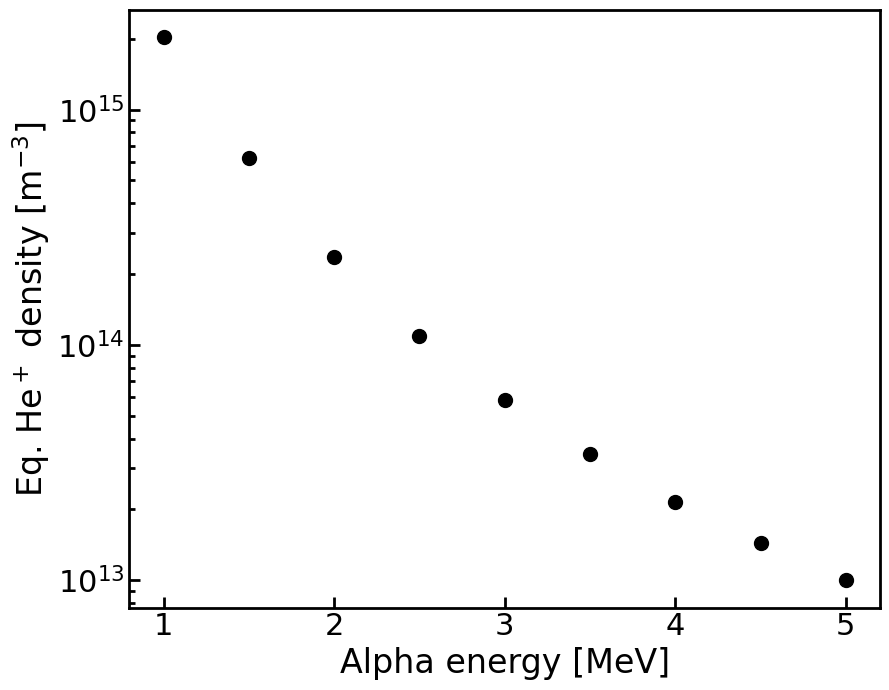

In [ ]:
for i,run in enumerate(E_He_scan):
    plt.scatter(E_He_list[i]/1e6, run.n_He1[-1], c='k')
plt.xlabel(r'Alpha energy [MeV]')
plt.ylabel(r'Eq. He$^+$ density [m$^{-3}$]')
plt.yscale('log')
#plt.savefig(f'plots/eq_alpha_energy.png', bbox_inches='tight')
plt.show()

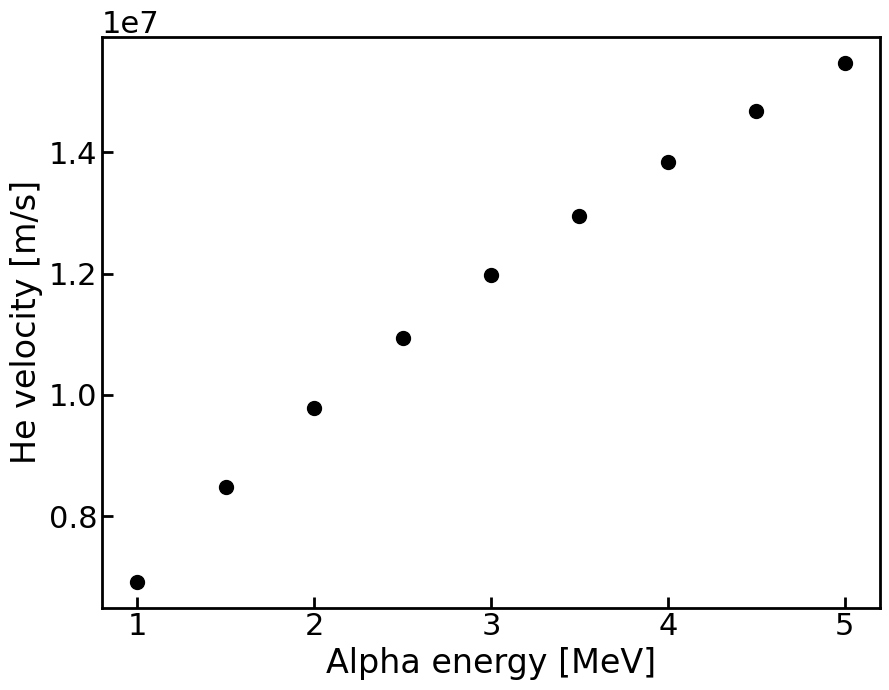

In [155]:
He_v = []
for i,run in enumerate(E_He_scan):
    plt.scatter(E_He_list[i]/1e6, run.v_He, c='k')
    He_v.append(run.v_He)
plt.xlabel(r'Alpha energy [MeV]')
plt.ylabel(r'He velocity [m/s]')
#plt.yscale('log')
#plt.savefig(f'plots/eq_alpha_energy.png', bbox_inches='tight')
plt.show()
He_v = np.array(He_v)

In [156]:
0.01/He_v

array([1.44496954e-09, 1.17981269e-09, 1.02174776e-09, 9.13878982e-10,
       8.34253555e-10, 7.72368710e-10, 7.22484772e-10, 6.81165175e-10,
       6.46210025e-10])

# Isotope effect

In [25]:
n_plasma = 1e20
T_plasma = 10e3
n_H = 1e22
T_H = 10
E_He = 1e6
dt = 1e-11
N = 100000
n_He0 = 1e16
m_plasma_list = [1,2,3]
m_plasma_scan = []

for m_plasma in m_plasma_list:
    m_plasma_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N, m_plasma=m_plasma))

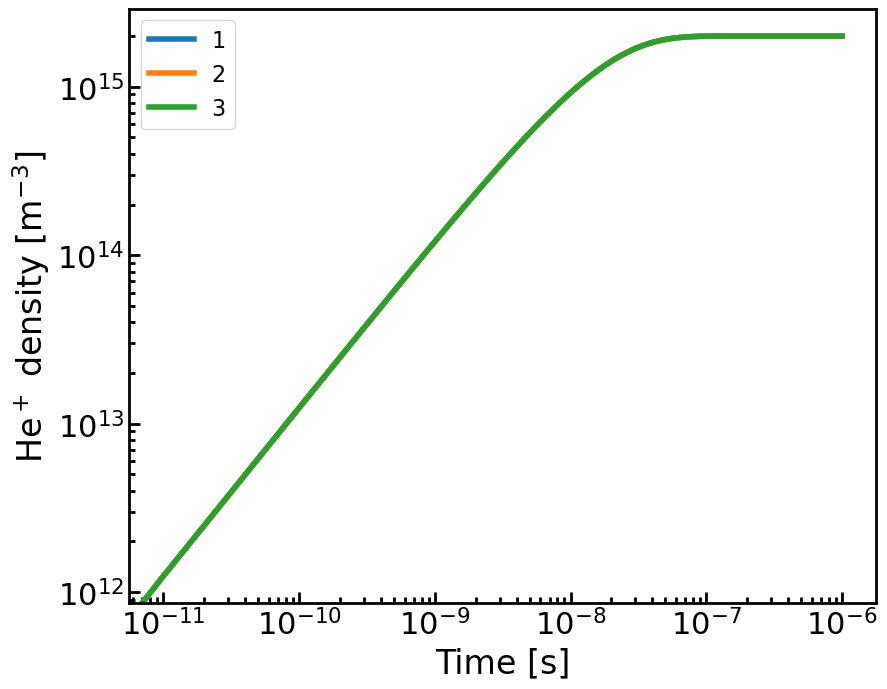

In [26]:
for run in m_plasma_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.legend(m_plasma_list, title=r'', fontsize=16, title_fontsize=16)
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
#plt.title('Alpha energy scan')
#plt.savefig(f'plots/alpha_energy.png', bbox_inches='tight')
plt.show()

In [27]:
for run in m_plasma_scan:
    print(run.n_He1[-1]/m_plasma_scan[0].n_He1[-1])

1.0
0.9998865961347859
0.9998477473675298


In [28]:
n_plasma = 1e20
T_plasma = 10e3
n_H = 1e22
T_H = 10
E_He = 1e6
dt = 1e-11
N = 100000
n_He0 = 1e16
m_cloud_list = [1,2,3]
m_cloud_scan = []

for m_H in m_cloud_list:
    m_cloud_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He0, cross_sections, dt, N, m_H=m_H))

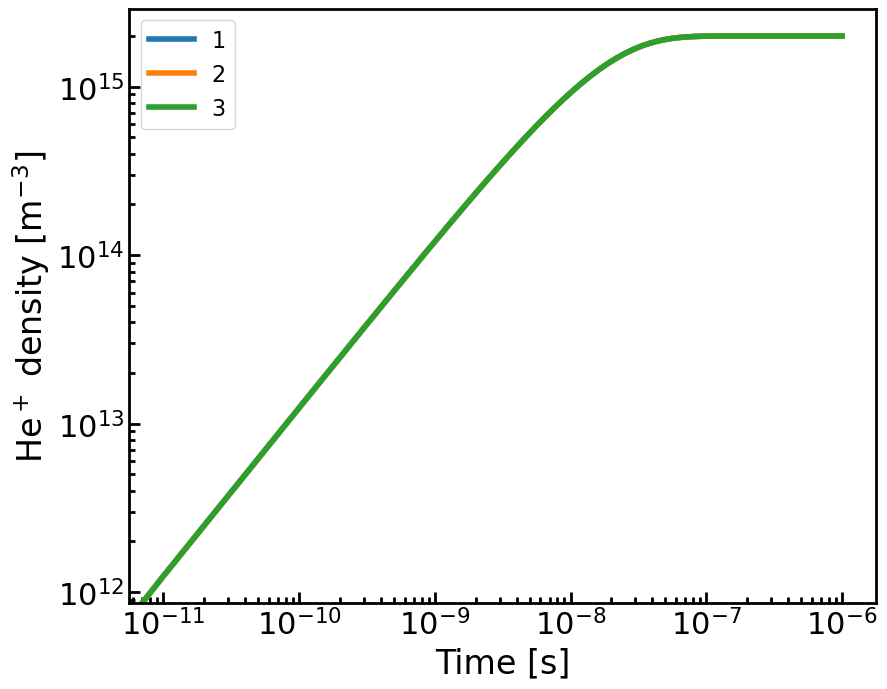

In [29]:
for run in m_cloud_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.legend(m_cloud_list, title=r'', fontsize=16, title_fontsize=16)
plt.ylabel(r'He$^+$ density [m$^{-3}$]')
plt.xlabel('Time [s]')
#plt.title('Alpha energy scan')
#plt.savefig(f'plots/alpha_energy.png', bbox_inches='tight')
plt.show()

In [30]:
for run in m_cloud_scan:
    print(run.n_He1[-1]/m_cloud_scan[0].n_He1[-1])

1.0
0.9998392112436697
0.9997856225710404


# He density

## Conservative

In [120]:
n_plasma = 1e20
T_plasma = 10e3
n_H = 1e22
T_H = 1e-2
E_He = 3.5e6
dt = 1e-11
N = 100000
n_He0_list = np.array([1e14, 1e15, 1e16, 1e17, 1e18, 1e19])
con_n_He_scan = []

for n_He in n_He0_list:
    con_n_He_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He, cross_sections, dt, N))

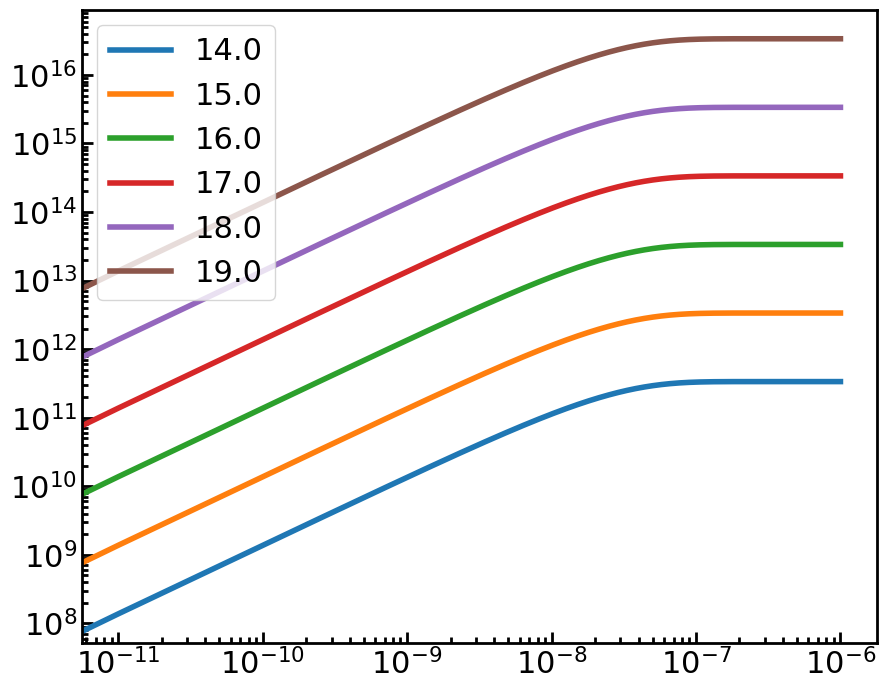

In [121]:
for run in con_n_He_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.legend(np.log10(n_He0_list))
plt.show()

## Optimist

In [124]:
n_plasma = 1e19
T_plasma = 10e3
n_H = 1e24
T_H = 1e-2
E_He = 1e6
dt = 1e-12
N = 10000
n_He0_list = np.array([1e14, 1e15, 1e16, 1e17, 1e18, 1e19])
opt_n_He_scan = []

for n_He in n_He0_list:
    opt_n_He_scan.append(PCX_run(n_plasma, T_plasma, n_H, T_H, E_He, n_He, cross_sections, dt, N))

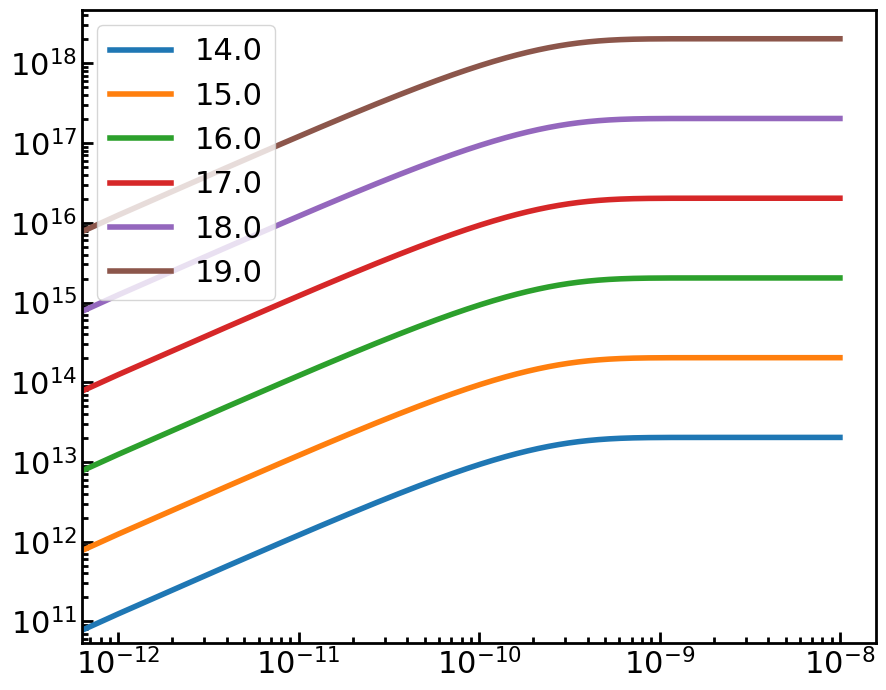

In [125]:
for run in opt_n_He_scan:
    plt.plot(run.time, run.n_He1)
plt.yscale('log')
plt.xscale('log')
plt.legend(np.log10(n_He0_list))
plt.show()

In [126]:
opt_res = []
con_res = []
for i,run in enumerate(opt_n_He_scan):
    opt_res.append(opt_n_He_scan[i].n_He1[-1])
    con_res.append(con_n_He_scan[i].n_He1[-1])
opt_res = np.array(opt_res)
con_res = np.array(con_res)

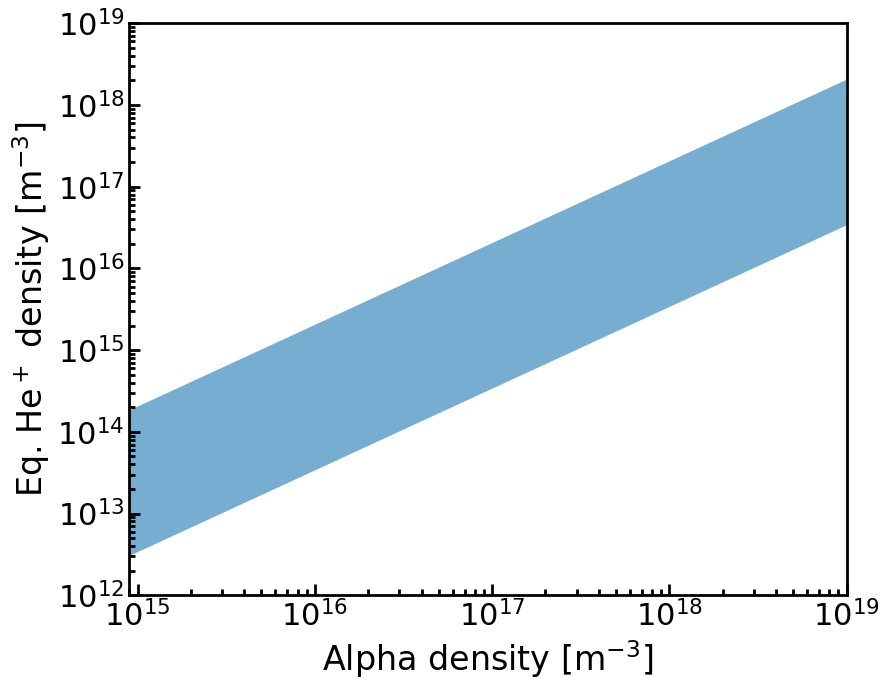

In [ ]:
plt.fill_between(n_He0_list, con_res, opt_res, alpha = 0.6)
plt.xlabel(r'Alpha density [m$^{-3}$]')
plt.ylabel(r'Eq. He$^+$ density [m$^{-3}$]')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.9e15, 1e19)
plt.ylim(1e12, 1e19)
#plt.savefig(f'plots/eq_density_estimate.png', bbox_inches='tight')
plt.show()

# Comparison

In [130]:
background_dens = 1e17 # ph/sr/sec/m2/nm Manfred vonHellerman in Progress in ITER diagnostics (to be published)
length = 0.01 #m
wavelength = 468 #nm
rate = 6.2e7 #/s
con_pop = 1e-2
opt_pop = 0.1
con_spectral_length = con_n_He_scan[0].v_He / 3e8 * wavelength * 2
opt_spectral_length = opt_n_He_scan[0].v_He / 3e8 * wavelength * 2
print(con_spectral_length, opt_spectral_length)

40.39521488717829 21.592150596133045


In [131]:
def exp_dist(rate, t):
    return rate*np.exp(-rate*t)

def effective_emission_rate(emission_rate, ion_rate, plot = False):
    t = np.linspace(1/ion_rate/20, 5/ion_rate, 50)
    rate = 1/t
    eff_rate = rate*(1-np.exp(-emission_rate/rate))
    dist = exp_dist(ion_rate,t)
    if plot:
        plt.plot(t,eff_rate)
        plt.plot(t,dist)
        plt.show()
    return np.trapz(dist*eff_rate, t)

def effective_emission_rate_factor(emission_rate, ion_rate, plot = False):
    t = np.linspace(1/ion_rate/100, 10/ion_rate, 100)
    eff_rate = (1-np.exp(-emission_rate*t))
    dist = exp_dist(ion_rate,t)
    if plot:
        plt.plot(t,eff_rate)
        plt.plot(t,dist*(t[1]-t[0]))
        plt.show()
        print(np.trapz(dist, t))
    return np.trapz(dist*eff_rate, t)

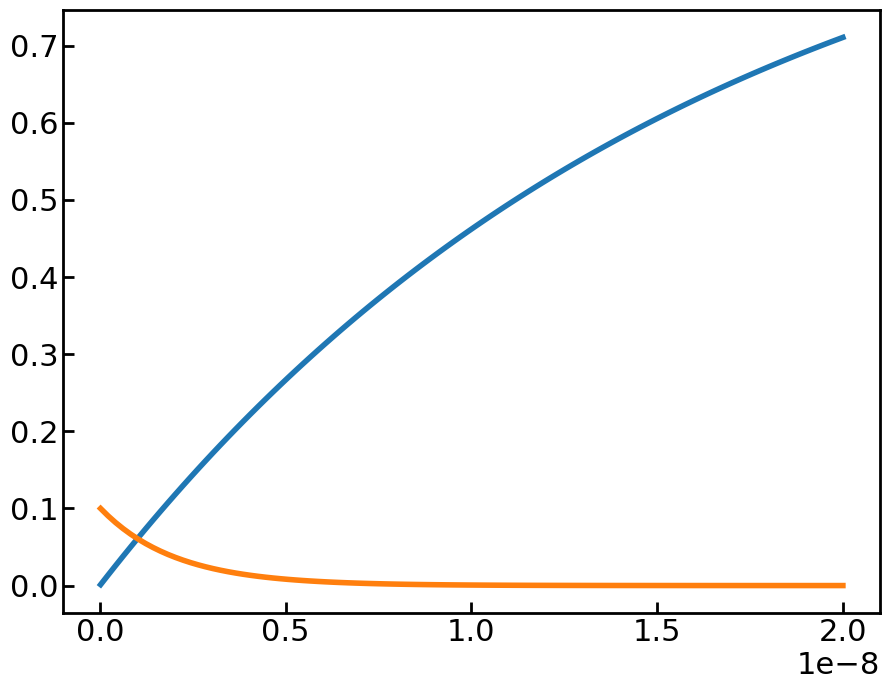

0.9908443632288794


0.11017744722934035

In [132]:
effective_emission_rate_factor(rate, 50e7, plot=True)

In [147]:
print(con_n_He_scan[0].R_He1_to_He2/1e7, opt_n_He_scan[0].R_He1_to_He2/1e7)

4.081561028776245 486.44961231788864


In [149]:
con_rate = rate*effective_emission_rate_factor(rate, con_n_He_scan[0].R_He1_to_He2)
opt_rate = rate*effective_emission_rate_factor(rate, opt_n_He_scan[0].R_He1_to_He2)
print(con_rate/1e7, opt_rate/1e5)


3.730283432089488 7.792062514928212


In [137]:
con_factor = con_pop*length*con_rate/4/np.pi/con_spectral_length # to get ph/sr/sec/m2/nm
opt_factor = opt_pop*length*opt_rate/4/np.pi/opt_spectral_length # to get ph/sr/sec/m2/nm
print(con_factor, opt_factor)

7.348556617522595 2.871750223791948


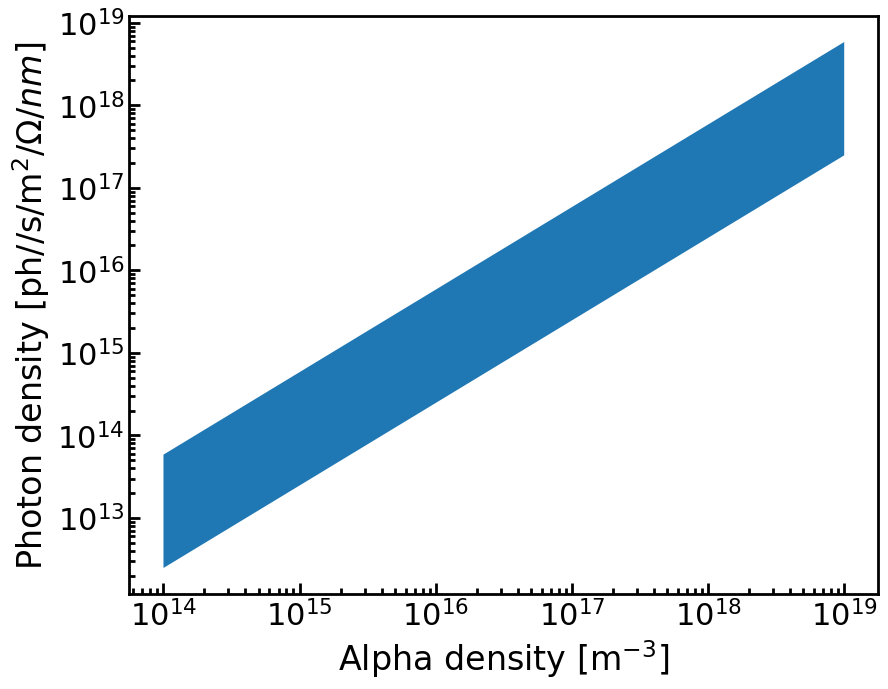

In [138]:
plt.fill_between(n_He0_list, con_res*con_factor, opt_res*opt_factor)
plt.xlabel(r'Alpha density [m$^{-3}$]')
plt.ylabel(r'Photon density [ph//s/m$^{2}/\Omega/nm$]')
plt.yscale('log')
plt.xscale('log')
#plt.savefig(f'plots/eq_alpha_density.png', bbox_inches='tight')
plt.show()

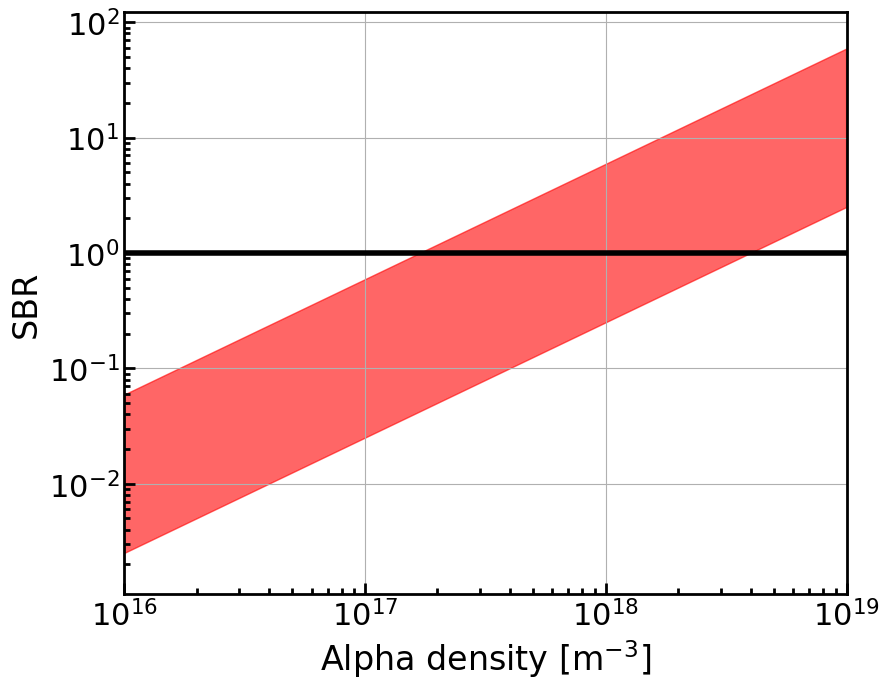

In [ ]:
plt.fill_between(n_He0_list, con_res*con_factor/background_dens, opt_res*opt_factor/background_dens, color='red', alpha = 0.6)
plt.plot([1e14, 1e20],[1,1], 'k')
plt.xlabel(r'Alpha density [m$^{-3}$]')
plt.ylabel('SBR')
plt.yscale('log')
plt.xscale('log')
plt.xlim(1e16, 1e19)
plt.ylim(bottom=1.1e-3)
plt.grid()
#plt.savefig(f'plots/eq_SBR_estimate.png', bbox_inches='tight')
plt.show()

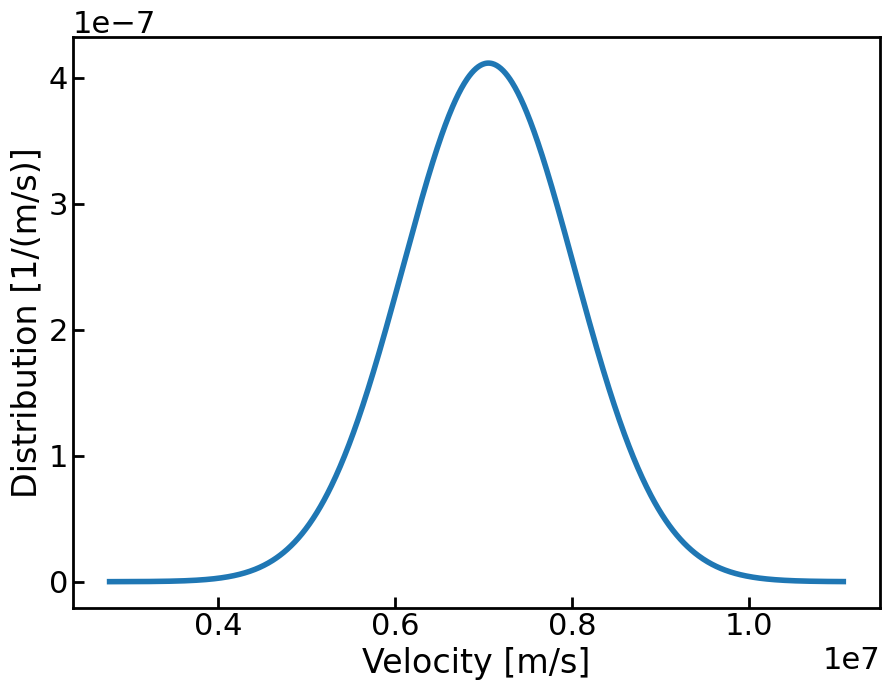

In [140]:
run = opt_n_He_scan[0]
#plt.plot(run.v_H, run.f_H)
plt.plot(run.v, run.f_plasma)
#plt.plot(run.v_e, run.f_e)
plt.xlabel('Velocity [m/s]')
plt.ylabel('Distribution [1/(m/s)]')
#plt.savefig(f'plots/p_dist.png', bbox_inches='tight')
plt.show()

In [47]:
np.trapz(run.f_e, run.v_e)

0.9997578524557408

In [48]:
(9.39e7 + 4.91e7 + 9.79e6 + 4.91e7 + 2.06e8 + 1.13e8 + 5.56e5 + 1.88e7 + 2.21e8 + 1.47e7 + 5.01e6 + 1.96e7 + 5.57e6)/13/1e7

6.20096923076923

# Levels

In [12]:
import os

In [13]:
level_files = os.listdir('../cross_sections/levels')
level_cross_sections = []

In [14]:
for f in level_files:
    _,projectile,product = f.split('_')
    product = product.split('.')[0] + '+'
    level_cross_sections.append(CrossSection(projectile, 'He2+', product, '../cross_sections/levels/'+f))

level_cross_sections = CrossSectionCollection(level_cross_sections)

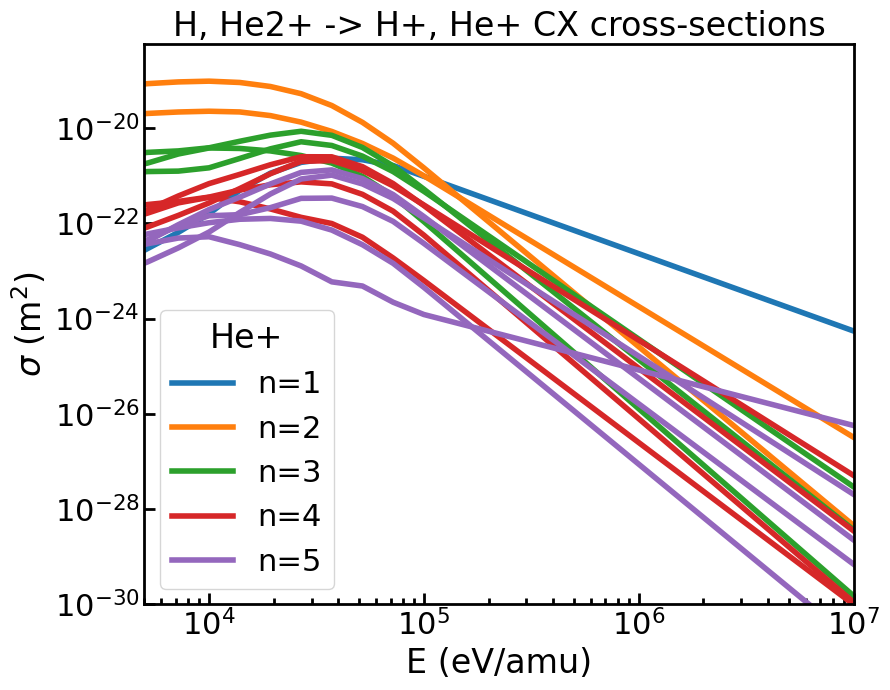

In [15]:
labels = [Line2D([], [], color='C0', label=f'n=1'),
          Line2D([], [], color='C1', label=f'n=2'),
          Line2D([], [], color='C2', label=f'n=3'),
          Line2D([], [], color='C3', label=f'n=4'),
          Line2D([], [], color='C4', label=f'n=5')]

test_E = 10**np.linspace(1, 8, 50)
levels_sum = [[], [], [], [], []]
for cross in level_cross_sections.cross_sections:
    values = cross.cross_section(test_E)
    if '1' in cross.product:
        plt.plot(test_E, values, 'C0')
        levels_sum[0].append(values)
    if '2' in cross.product:
        plt.plot(test_E, values, 'C1')
        levels_sum[1].append(values)
    if '3' in cross.product:
        plt.plot(test_E, values, 'C2')
        levels_sum[2].append(values)
    if '4' in cross.product:
        plt.plot(test_E, values, 'C3')
        levels_sum[3].append(values)
    if '5' in cross.product:
        plt.plot(test_E, values, 'C4')
        levels_sum[4].append(values)
plt.yscale('log')
plt.xscale('log')
plt.ylim(bottom = 1e-30)
plt.xlim(left = 5e3, right = 1e7)
plt.xlabel('E (eV/amu)')
plt.ylabel(r'$\sigma$ (m$^2$)')
plt.legend(handles = labels, title='He+')
plt.title('H, He2+ -> H+, He+ CX cross-sections')
#plt.savefig(f'plots/levels_all_cross_sections.png', bbox_inches='tight')
plt.show()

In [53]:
for i,level in enumerate(levels_sum):
    if len(level) > 1:
        levels_sum[i] = np.sum(np.array(level), axis=0)
    else:
        levels_sum[i] = level[0]

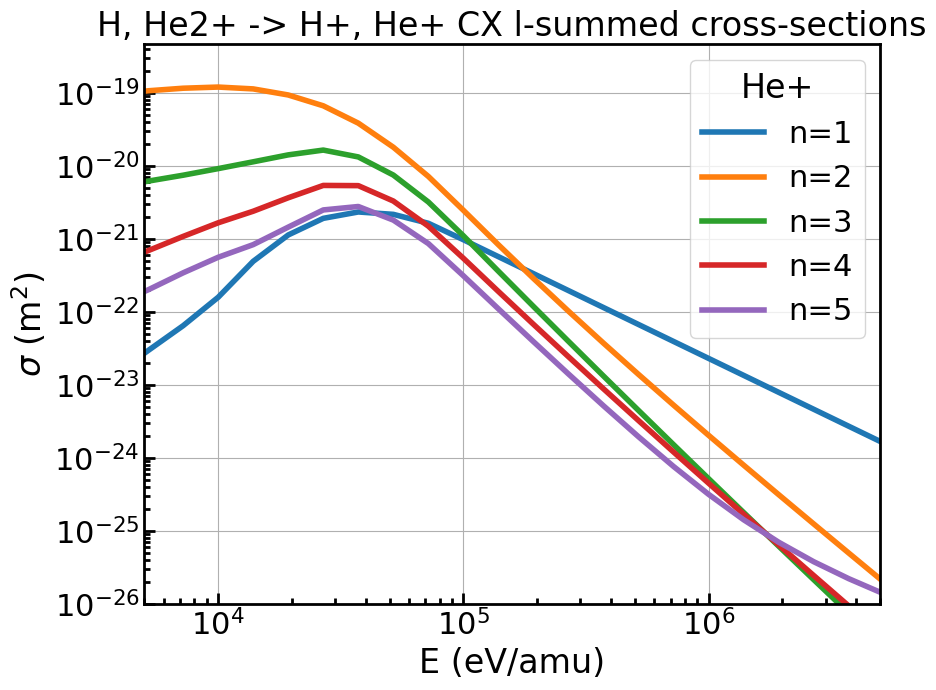

In [54]:
for level in levels_sum:
    plt.plot(test_E, level)
plt.yscale('log')
plt.xscale('log')
plt.ylim(bottom = 1e-26)
plt.xlim(left = 5e3, right = 5e6)
plt.xlabel('E (eV/amu)')
plt.ylabel(r'$\sigma$ (m$^2$)')
plt.legend([f'n={i+1}' for i in range(5)], title = 'He+')
plt.title('H, He2+ -> H+, He+ CX l-summed cross-sections')
plt.grid()
#plt.savefig(f'plots/levels_sum_cross_sections.png', bbox_inches='tight')
plt.show()

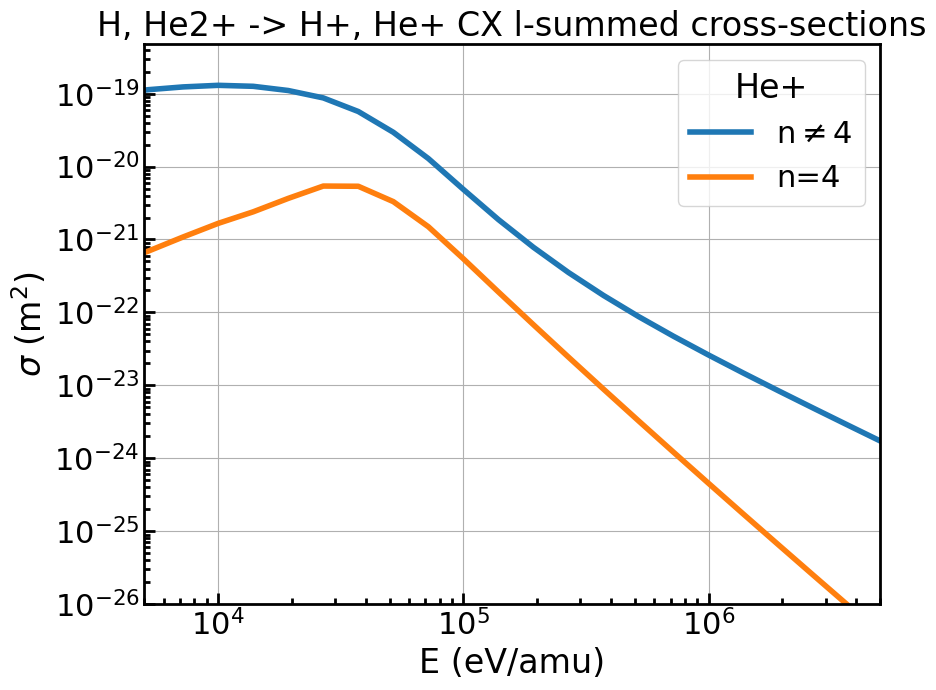

In [157]:
other_levels = levels_sum[0] + levels_sum[1] + levels_sum[2] + levels_sum[4]

plt.plot(test_E, other_levels)
plt.plot(test_E, levels_sum[3])
plt.yscale('log')
plt.xscale('log')
plt.ylim(bottom = 1e-26)
plt.xlim(left = 5e3, right = 5e6)
plt.xlabel('E (eV/amu)')
plt.ylabel(r'$\sigma$ (m$^2$)')
plt.legend([r'n$\neq$4', 'n=4'], title = 'He+')
plt.title('H, He2+ -> H+, He+ CX l-summed cross-sections')
plt.grid()
#plt.savefig(f'plots/levels_4vs_else.png', bbox_inches='tight')
plt.show()

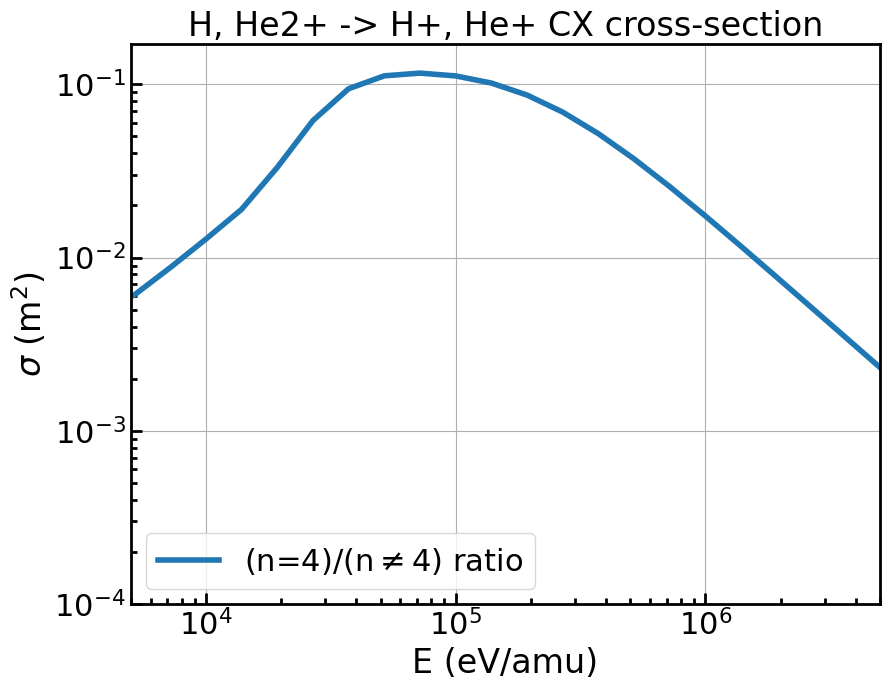

In [56]:
plt.plot(test_E, levels_sum[3]/other_levels)
plt.yscale('log')
plt.xscale('log')
plt.xlim(left = 5e3, right = 5e6)
plt.ylim(bottom = 1e-4)
plt.xlabel('E (eV/amu)')
plt.ylabel(r'$\sigma$ (m$^2$)')
plt.legend([r'(n=4)/(n$\neq$4) ratio'])
plt.title('H, He2+ -> H+, He+ CX cross-section')
plt.grid()
#plt.savefig(f'plots/levels_4_ratio.png', bbox_inches='tight')
plt.show()